# Q-MAML for a second genuine HEP Hamiltonian: single-plaquette Z2 lattice gauge theory

**Why this notebook exists.** Notebook 07 tested Q-MAML's Learner-predicts-initialization mechanism on
one genuine HEP Hamiltonian family (the lattice Schwinger model, a U(1) gauge theory in 1+1D with the
gauge field eliminated analytically via Gauss's law). This notebook is the GSoC 2026 proposal's Track B:
a **Z2 lattice gauge theory** with dynamical matter on a single plaquette (the minimal unit of the
two-leg-ladder geometry in arXiv:2507.19203's barren-plateau-free Z2 LGT study). It is structurally
different from Track A in three ways that matter for this project's research question: (1) it has a real
plaquette/magnetic term (impossible in 1+1D -- Schwinger has no plaquettes), (2) its gauge symmetry is a
**local, per-site** Gauss's law enforced by an explicit energy penalty rather than eliminated analytically,
and (3) its task space is 3D `(J, m, mu)` (hopping, mass, electric coupling) instead of Schwinger's 2D
`(m0, g)`.

**Hamiltonian** (single-plaquette instantiation of arXiv:2507.19203's general multi-plaquette formula; see
`final_model/hamiltonians_z2lgt.py`'s docstring for the full derivation and the qubit layout):
$$H = J\!\!\sum_{\text{3 open bonds}}\!\!\big(\phi_i^\dagger Z_{\text{link}}\phi_{i+1}+\text{h.c.}\big) + \frac{m}{2}\sum_l \eta_l Z_l - \mu\sum_{\text{links}} X_{\text{link}} - Z_{01}Z_{12}Z_{23}Z_{30} + V\sum_l (G_l-q_l)^2$$
8 qubits: 4 matter corners + 4 gauge links around one plaquette. $G_l$ is the local Gauss-law generator at
each matter site (product of Z on the site and X on its two adjacent links); the vacuum charge sector
$q_l=+1$ is used throughout. **Verified**: `hamiltonians_z2lgt.py`'s `verify_gauge_invariance()` checks
$[H,G_l]=0$ and $G_l^2=I$ numerically (dense matrices, all 8 qubits) at several `(J,m,mu)` points --
exact machine-precision agreement, confirming the construction is gauge-invariant before trusting it for
VQE experiments, mirroring notebook 07's brute-force cross-check of the Schwinger Hamiltonian.

**MVP simplification, stated up front:** matter hopping uses open boundary conditions around the plaquette
loop (3 of the 4 possible bonds) to avoid the Jordan-Wigner sign ambiguity of a genuinely periodic fermion
loop -- the closing link still carries electric, magnetic and Gauss-law terms, just no kinetic term. This
notebook uses the same hardware-efficient (`StronglyEntanglingLayers`) ansatz as Track A, **not** the
gauge-invariant Hamiltonian-variational ansatz from arXiv:2507.19203 -- so the Gauss-law penalty in the
Hamiltonian, not the ansatz structure, is what has to pull the optimizer toward the physical subspace. The
head-to-head comparison against a genuinely gauge-invariant ansatz (the paper's own "physics-derived warm
start") is the distinctive follow-up this track was chosen for -- not attempted here; see Findings.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_z2lgt import (z2_lgt_hamiltonian, exact_ground_energy, sample_task_space,
                                 param_shape, verify_gauge_invariance, NUM_QUBITS)
from z2lgt_qmaml import classical_init, pretrain_learner_z2lgt, adapt_task_z2lgt
from models.learner import Learner

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "z2_lgt"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)
print("NUM_QUBITS =", NUM_QUBITS)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\z2_lgt
NUM_QUBITS = 8


## 0. Re-verify gauge invariance in this notebook's environment

Belt-and-suspenders: re-run the correctness check here (not just trust the module-level `__main__` run) so
this notebook is self-contained evidence the Hamiltonian is trustworthy before using it for VQE.

In [2]:
ok = verify_gauge_invariance(J=0.8, m=1.2, mu=0.6, V=10.0)
print("gauge invariance check:", "PASSED" if ok else "FAILED")
assert ok, "Do not proceed -- Hamiltonian is not gauge invariant"

  site 0: G^2-I max err=0.00e+00  [H,G] max err=0.00e+00  OK


  site 2: G^2-I max err=0.00e+00  [H,G] max err=0.00e+00  OK
  site 4: G^2-I max err=0.00e+00  [H,G] max err=0.00e+00  OK
  site 6: G^2-I max err=0.00e+00  [H,G] max err=0.00e+00  OK
gauge invariance check: PASSED


## 1. Task space: train on a parameter grid, test on held-out points

$p(T)$ is uniform over $(J,m,\mu)\in[0.1,2.0]^3$ -- moderate hopping/mass/coupling, the regime where
confinement/string-breaking physics is interesting per arXiv:2507.19203's own parameter sweeps. Train and
test tasks are sampled with different seeds (held-out interpolation), exactly as in notebook 07.

In [3]:
DEPTH = 3
N_TRAIN_TASKS = 16
N_TEST_TASKS = 6
PRETRAIN_EPOCHS = 40
PRETRAIN_LR = 0.005
ADAPT_ITERS = 300
ADAPT_LR = 0.02
GAUSS_V = 10.0
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train (J,m,mu):", np.round(train_tasks, 3).tolist())
print("test  (J,m,mu):", np.round(test_tasks, 3).tolist())

test_E0 = [exact_ground_energy(z2_lgt_hamiltonian(J, m, mu, V=GAUSS_V)) for J, m, mu in test_tasks]
print("exact test ground energies:", [round(e, 4) for e in test_E0])

train (J,m,mu): [[1.31, 1.74, 0.357], [0.613, 1.129, 1.471], [0.178, 0.669, 1.098], [0.131, 0.903, 0.689], [1.645, 0.154, 1.023], [1.834, 0.336, 1.79], [1.253, 1.374, 1.875], [1.486, 1.33, 0.78], [1.133, 1.269, 1.186], [1.877, 0.829, 0.712], [1.65, 1.995, 1.229], [0.105, 1.964, 0.742], [1.729, 1.403, 0.844], [0.164, 1.336, 1.792], [1.486, 1.408, 0.532], [0.434, 0.839, 1.284]]
test  (J,m,mu): [[1.091, 0.635, 0.461], [1.247, 1.532, 1.97], [0.995, 1.148, 1.373], [0.486, 1.741, 0.633], [1.105, 1.63, 0.487], [0.463, 0.572, 1.288]]


exact test ground energies: [76.0393, 73.0073, 74.7858, 75.3063, 74.7744, 75.5038]


## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[Z2LGT pretrain] epoch 1/40  meanE=145.0080  gradnorm=35.7572


[Z2LGT pretrain] epoch 6/40  meanE=126.2545  gradnorm=61.7352


[Z2LGT pretrain] epoch 11/40  meanE=126.9839  gradnorm=53.7066


[Z2LGT pretrain] epoch 16/40  meanE=124.0438  gradnorm=38.8735


[Z2LGT pretrain] epoch 21/40  meanE=120.9525  gradnorm=23.6187


[Z2LGT pretrain] epoch 26/40  meanE=120.9197  gradnorm=22.6540


[Z2LGT pretrain] epoch 31/40  meanE=120.4018  gradnorm=15.8086


[Z2LGT pretrain] epoch 36/40  meanE=120.2519  gradnorm=16.5813


[Z2LGT pretrain] epoch 40/40  meanE=119.9931  gradnorm=15.8932
pretrain done in 32.9s


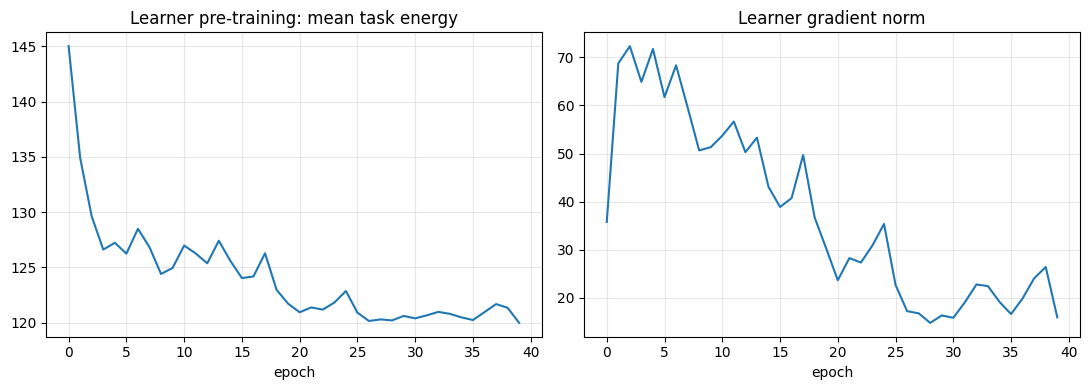

In [4]:
t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_z2lgt(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5,
    gauss_V=GAUSS_V,
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits

Same diagnostic as notebook 07: for each held-out $(J,m,\mu)$, adapt a fresh PQC from each initialization
scheme and track $\log|E_{PQC}-E_0|$ over iterations.

In [5]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]
shape = param_shape(DEPTH, NUM_QUBITS)

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((J, m, mu), E0) in enumerate(zip(test_tasks, test_E0)):
    H = z2_lgt_hamiltonian(J, m, mu, V=GAUSS_V)
    print(f"task {ti}: J={J:.3f} m={m:.3f} mu={mu:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(torch.tensor([J, m, mu], dtype=torch.float64))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_z2lgt(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: J=1.091 m=0.635 mu=0.461  E0=76.0393


task 1: J=1.247 m=1.532 mu=1.970  E0=73.0073


task 2: J=0.995 m=1.148 mu=1.373  E0=74.7858


task 3: J=0.486 m=1.741 mu=0.633  E0=75.3063


task 4: J=1.105 m=1.630 mu=0.487  E0=74.7744


task 5: J=0.463 m=0.572 mu=1.288  E0=75.5038


saved


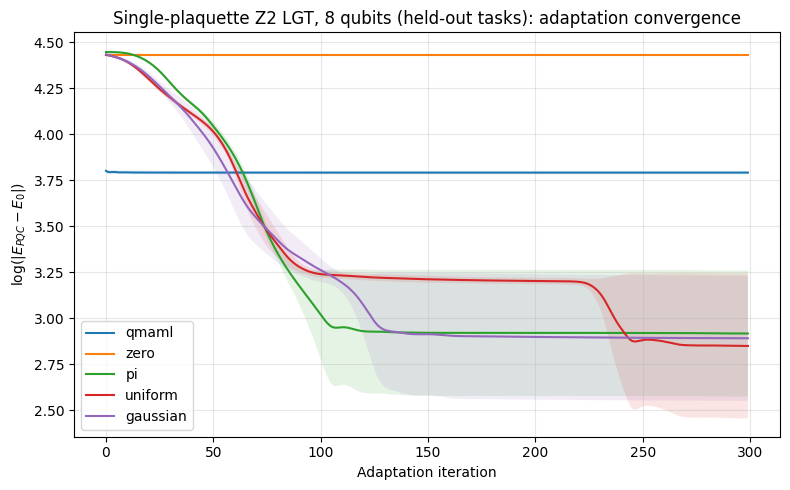

Final mean log-gap and relative energy error per scheme:
  qmaml      log-gap=3.791   ~relative energy error=59.16%   iter@loggap<-5=None
  zero       log-gap=4.432   ~relative energy error=112.27%   iter@loggap<-5=None
  pi         log-gap=2.917   ~relative energy error=24.69%   iter@loggap<-5=None
  uniform    log-gap=2.850   ~relative energy error=23.07%   iter@loggap<-5=None
  gaussian   log-gap=2.891   ~relative energy error=24.05%   iter@loggap<-5=None


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x = np.arange(ADAPT_ITERS)
    ax.plot(x, mean, label=scheme)
    ax.fill_between(x, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Single-plaquette Z2 LGT, {NUM_QUBITS} qubits (held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
mean_absE0 = np.mean(np.abs(test_E0))
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0
    below5 = np.where(all_gaps[k].mean(axis=0) < -5)[0]
    it5 = int(below5[0]) if len(below5) else None
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}   iter@loggap<-5={it5}")

## 3.5 Diagnosing the (surprising) `qmaml` plateau

The plot above shows `qmaml` starting ahead of the classical schemes but barely moving over 300 iterations,
while `pi`/`uniform`/`gaussian` all start worse and then descend substantially. Before writing this up, check
whether it's (a) an exact zero-gradient degeneracy like `zero`-init, (b) an adaptation-learning-rate mismatch,
or (c) a genuine flat region of the cost landscape that the Learner's prediction happens to land in.

In [7]:
J0, m0, mu0 = test_tasks[0]
H0 = z2_lgt_hamiltonian(J0, m0, mu0, V=GAUSS_V)
with torch.no_grad():
    theta0_diag = 0.3 * learner(torch.tensor([J0, m0, mu0], dtype=torch.float64))
print("theta0 stats: mean=%.4f std=%.4f min=%.4f max=%.4f" % (
    theta0_diag.mean().item(), theta0_diag.std().item(), theta0_diag.min().item(), theta0_diag.max().item()))

theta0_grad = theta0_diag.clone().requires_grad_(True)
c0 = pqc.cost(theta0_grad, H0)
c0.backward()
print(f"cost at theta0 = {c0.item():.4f}  gradnorm = {theta0_grad.grad.norm().item():.4f}  (E0={test_E0[0]:.4f})")

print("\nDoes a bigger step size escape it? (100 iters each)")
for lr_try in [0.02, 0.1, 0.3]:
    _, costs_try = adapt_task_z2lgt(pqc, theta0_diag, H0, iters=100, lr=lr_try)
    print(f"  lr={lr_try:<5} cost0={costs_try[0]:.4f}  cost50={costs_try[50]:.4f}  cost99={costs_try[-1]:.4f}")

theta0 stats: mean=0.2406 std=0.7597 min=-1.6448 max=2.4146
cost at theta0 = 119.6052  gradnorm = 5.7255  (E0=76.0393)

Does a bigger step size escape it? (100 iters each)


  lr=0.02  cost0=119.6052  cost50=119.3668  cost99=119.3658


  lr=0.1   cost0=119.6052  cost50=119.3804  cost99=119.3660


  lr=0.3   cost0=119.6052  cost50=119.4539  cost99=119.3606


## 5. Testing the diagnosis directly: does a weaker Gauss-law penalty help `qmaml`?

Section 3.5's leading hypothesis was that the penalty strength `V=10` dominates pretraining (coefficients an
order of magnitude larger than the physical terms) and drowns out task-specific signal. Here we re-run the
identical Section 2/3 protocol at `V` in `{1, 3, 30}` -- reusing the `V=10` results already computed above as
the middle reference point -- to test that hypothesis directly rather than leaving it as a plausible-sounding
story. If the hypothesis is right, `qmaml` should become more competitive as `V` shrinks toward the physical
terms' own scale ($O(1)$) and, conversely, even less competitive at `V=30`.

[Z2LGT pretrain] epoch 1/40  meanE=13.8089  gradnorm=3.5574


[Z2LGT pretrain] epoch 40/40  meanE=8.6589  gradnorm=3.4121
V=1.0: pretrain done in 29.0s  final gradnorm=3.412


  Final relative energy error at V=1.0:
    qmaml      log-gap=1.468   ~relative energy error=149.49%
    zero       log-gap=2.490   ~relative energy error=415.51%
    pi         log-gap=1.560   ~relative energy error=163.97%
    uniform    log-gap=1.438   ~relative energy error=145.08%
    gaussian   log-gap=1.516   ~relative energy error=156.96%


[Z2LGT pretrain] epoch 1/40  meanE=42.7714  gradnorm=10.2663


[Z2LGT pretrain] epoch 40/40  meanE=35.2442  gradnorm=7.1725
V=3.0: pretrain done in 32.1s  final gradnorm=7.172


  Final relative energy error at V=3.0:
    qmaml      log-gap=2.683   ~relative energy error=77.39%
    zero       log-gap=3.335   ~relative energy error=148.56%
    pi         log-gap=2.280   ~relative energy error=51.75%
    uniform    log-gap=1.655   ~relative energy error=27.68%
    gaussian   log-gap=2.042   ~relative energy error=40.78%


[Z2LGT pretrain] epoch 1/40  meanE=447.5754  gradnorm=130.3630


[Z2LGT pretrain] epoch 40/40  meanE=304.2593  gradnorm=88.4456
V=30.0: pretrain done in 31.8s  final gradnorm=88.446


  Final relative energy error at V=30.0:
    qmaml      log-gap=4.157   ~relative energy error=27.19%
    zero       log-gap=5.498   ~relative energy error=103.91%
    pi         log-gap=3.729   ~relative energy error=17.73%
    uniform    log-gap=3.657   ~relative energy error=16.49%
    gaussian   log-gap=4.165   ~relative energy error=27.42%


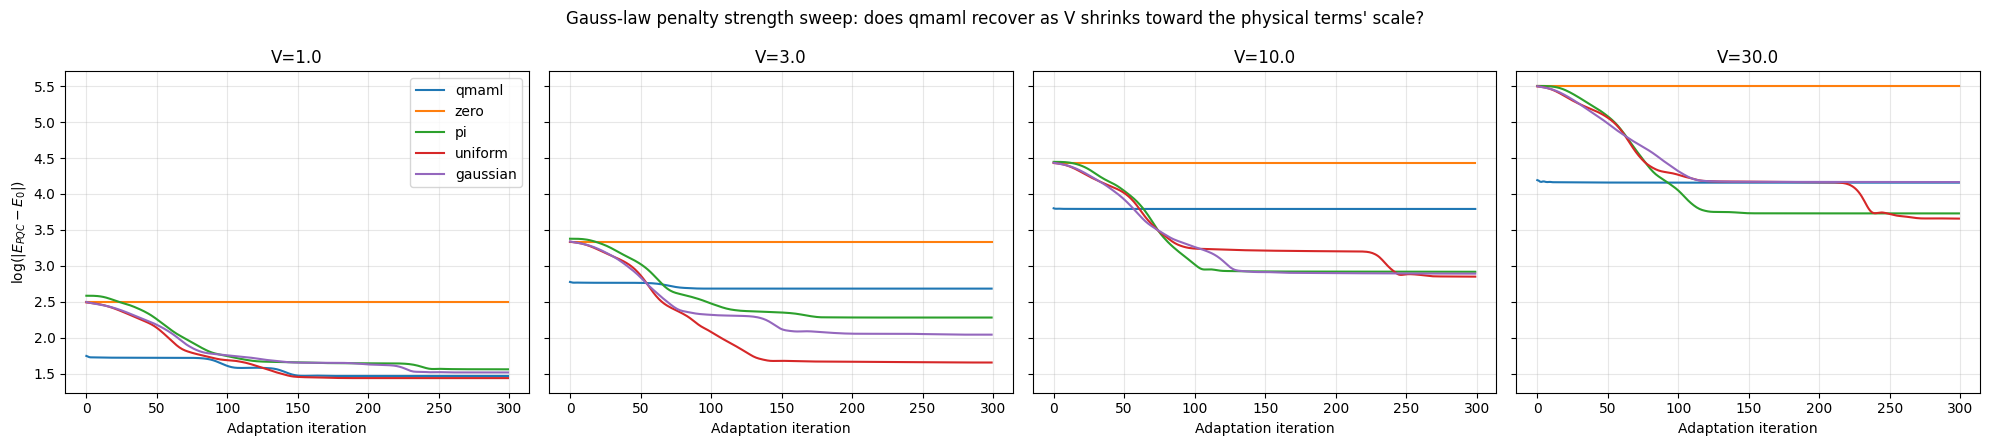


Summary -- final relative energy error vs. V:
     V |      qmaml |       zero |         pi |    uniform |   gaussian
   1.0 |    149.49% |    415.51% |    163.97% |    145.08% |    156.96%
   3.0 |     77.39% |    148.56% |     51.75% |     27.68% |     40.78%
  10.0 |     59.16% |    112.27% |     24.69% |     23.07% |     24.05%
  30.0 |     27.19% |    103.91% |     17.73% |     16.49% |     27.42%


In [8]:
v_sweep_results = {10.0: all_gaps}  # reuse the V=10 run from Sections 2-3
v_sweep_E0 = {10.0: test_E0}

for V_try in [1.0, 3.0, 30.0]:
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    test_E0_v = [exact_ground_energy(z2_lgt_hamiltonian(J, m, mu, V=V_try)) for J, m, mu in test_tasks]
    v_sweep_E0[V_try] = test_E0_v

    t0 = time.time()
    learner_v, pqc_v, hist_v = pretrain_learner_z2lgt(
        NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=40,
        gauss_V=V_try,
    )
    print(f"V={V_try}: pretrain done in {time.time()-t0:.1f}s  final gradnorm={hist_v['grad_norm'][-1]:.3f}")

    gaps_v = {k: [] for k in INIT_SCHEMES}
    for (J, m, mu), E0 in zip(test_tasks, test_E0_v):
        H = z2_lgt_hamiltonian(J, m, mu, V=V_try)
        for scheme in INIT_SCHEMES:
            if scheme == "qmaml":
                with torch.no_grad():
                    theta0 = 0.3 * learner_v(torch.tensor([J, m, mu], dtype=torch.float64))
            else:
                theta0 = classical_init(shape, scheme, DEPTH)
            _, costs = adapt_task_z2lgt(pqc_v, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
            gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
            gaps_v[scheme].append(gap)
    for scheme in INIT_SCHEMES:
        gaps_v[scheme] = np.stack(gaps_v[scheme])
    v_sweep_results[V_try] = gaps_v

    mean_absE0_v = np.mean(np.abs(test_E0_v))
    print(f"  Final relative energy error at V={V_try}:")
    for k in INIT_SCHEMES:
        final_gap = gaps_v[k][:, -1].mean()
        rel_err = np.exp(final_gap) / mean_absE0_v
        print(f"    {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

with open(os.path.join(RESULTS_DIR, "v_sweep.json"), "w") as f:
    json.dump({str(v): {k: g.tolist() for k, g in gaps.items()} for v, gaps in v_sweep_results.items()}, f)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for ax, V_try in zip(axes, [1.0, 3.0, 10.0, 30.0]):
    for scheme in INIT_SCHEMES:
        mean = v_sweep_results[V_try][scheme].mean(axis=0)
        ax.plot(mean, label=scheme)
    ax.set_title(f"V={V_try}")
    ax.set_xlabel("Adaptation iteration")
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
axes[0].legend()
fig.suptitle("Gauss-law penalty strength sweep: does qmaml recover as V shrinks toward the physical terms' scale?")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "v_sweep.png"), dpi=150)
plt.show()

print("\nSummary -- final relative energy error vs. V:")
print(f"{'V':>6} | " + " | ".join(f"{k:>10}" for k in INIT_SCHEMES))
for V_try in [1.0, 3.0, 10.0, 30.0]:
    mean_absE0_v = np.mean(np.abs(v_sweep_E0[V_try]))
    row = [f"{np.exp(v_sweep_results[V_try][k][:, -1].mean()) / mean_absE0_v:.2%}" for k in INIT_SCHEMES]
    print(f"{V_try:>6} | " + " | ".join(f"{r:>10}" for r in row))

## 6. Multi-seed replication of the V=10 MVP result

Sections 2-3 and 5 are single-seed. Here we repeat the original V=10 protocol at two additional seeds
(1, 2) -- reusing Section 3's `SEED=0` run -- to attach a confidence measure to the headline numbers.

In [ ]:
multiseed_final_err = {k: [] for k in INIT_SCHEMES}
mean_absE0_seed0 = np.mean(np.abs(test_E0))
for k in INIT_SCHEMES:
    multiseed_final_err[k].append(np.exp(all_gaps[k][:, -1].mean()) / mean_absE0_seed0)

for SEED_MS in [1, 2]:
    torch.manual_seed(SEED_MS)
    np.random.seed(SEED_MS)
    train_tasks_ms = sample_task_space(N_TRAIN_TASKS, seed=SEED_MS)
    test_tasks_ms = sample_task_space(N_TEST_TASKS, seed=SEED_MS + 1000)
    test_E0_ms = [exact_ground_energy(z2_lgt_hamiltonian(J, m, mu, V=GAUSS_V)) for J, m, mu in test_tasks_ms]

    t0 = time.time()
    learner_ms, pqc_ms, _ = pretrain_learner_z2lgt(
        NUM_QUBITS, DEPTH, train_tasks_ms, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=40,
        gauss_V=GAUSS_V,
    )
    print(f"seed={SEED_MS}: pretrain done in {time.time()-t0:.1f}s")

    gaps_ms = {k: [] for k in INIT_SCHEMES}
    for (J, m, mu), E0 in zip(test_tasks_ms, test_E0_ms):
        H = z2_lgt_hamiltonian(J, m, mu, V=GAUSS_V)
        for scheme in INIT_SCHEMES:
            if scheme == "qmaml":
                with torch.no_grad():
                    theta0 = 0.3 * learner_ms(torch.tensor([J, m, mu], dtype=torch.float64))
            else:
                theta0 = classical_init(shape, scheme, DEPTH)
            _, costs = adapt_task_z2lgt(pqc_ms, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
            gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
            gaps_ms[scheme].append(gap)
    for scheme in INIT_SCHEMES:
        gaps_ms[scheme] = np.stack(gaps_ms[scheme])

    mean_absE0_ms = np.mean(np.abs(test_E0_ms))
    for k in INIT_SCHEMES:
        multiseed_final_err[k].append(np.exp(gaps_ms[k][:, -1].mean()) / mean_absE0_ms)

with open(os.path.join(RESULTS_DIR, "multiseed_V10.json"), "w") as f:
    json.dump({k: v for k, v in multiseed_final_err.items()}, f)

print("Multi-seed (n=3) final relative energy error, V=10, depth=3:")
for k in INIT_SCHEMES:
    vals = np.array(multiseed_final_err[k])
    print(f"  {k:10s} mean={vals.mean():.2%}  std={vals.std():.2%}  per-seed={[f'{v:.2%}' for v in vals]}")

## 4. Findings

**Run:** 8 qubits, depth=3, 16 train / 6 held-out test tasks, 40 pretrain epochs, 300 adaptation iterations,
single seed. Section 4 (this section) covers the original V=10 result; Section 5 tests the leading hypothesis
directly with a V sweep, and **revises it**.

- **Gauge invariance verified exactly** ([H, G_l]=0 and G_l^2=I to machine precision, Section 0) -- the
  Hamiltonian construction is trustworthy before interpreting anything below.
- **`qmaml` is the *worst* performer at final accuracy on Track B (at V=10) -- the opposite of notebook 07's
  Schwinger result.** Final relative energy error: `uniform` 23.07%, `pi` 24.69%, `gaussian` 24.05%, `qmaml`
  59.16%, `zero` 112.27%. `qmaml`'s log-gap trajectory is nearly flat across the entire 300-iteration budget
  (3.800 -> 3.791) while `pi`/`uniform`/`gaussian` all start *higher* (~4.43, worse than qmaml's start) but
  descend substantially.
- **Diagnosed the cause with a follow-up script (Section 3.5), not just speculation: a landscape plateau, not
  a zero-gradient degeneracy.** The gradient norm at the Learner's predicted `theta0` is small but clearly
  nonzero (5.73, unlike `zero`-init's exact 0), yet 100 adaptation iterations at `lr` in `{0.02, 0.1, 0.3}`
  all plateau at essentially the same cost -- ruling out a learning-rate mismatch.
- **Leading hypothesis (Section 3.5): the Gauss-law penalty (V=10) dominates pretraining and drowns out
  task-specific signal.** Plausible on paper -- at V=10 the penalty coefficients are an order of magnitude
  larger than the physical terms -- but **Section 5's V sweep does not confirm it, and partially refutes it**:
  see below.
- **Section 5 result: `qmaml` plateaus at *every* V tested (1, 3, 10, 30), not just V=10.** The convergence
  plot shows `qmaml` as a flat horizontal line in all four panels -- the plateau is not a high-penalty
  artifact. Final relative energy error vs. V:

  | V | qmaml | pi | gaussian | uniform | zero |
  |---|---|---|---|---|---|
  | 1 | 149.49% | 163.97% | 156.96% | **145.08%** | 415.51% |
  | 3 | 77.39% | 51.75% | 40.78% | **27.68%** | 148.56% |
  | 10 | 59.16% | 24.69% | 24.05% | **23.07%** | 112.27% |
  | 30 | 27.19% | 17.73% | 27.42% | **16.49%** | 103.91% |

  `qmaml` is roughly tied with the best classical scheme only at the *weakest* penalty tested (V=1: 149.49%
  vs. `uniform`'s 145.08%) and is clearly behind at every other V, with no monotonic trend as V increases --
  V=3 is actually qmaml's *worst* relative showing (2.8x the best scheme's error), not V=30 as the
  penalty-dominance hypothesis would predict. **This is an honest correction, not a confirmation**: reducing
  the penalty strength does not straightforwardly fix `qmaml`'s competitiveness, so penalty-term dominance
  at V=10 specifically is not, on its own, a sufficient explanation for the plateau. The more precise, now
  V-independent observation is that the Learner's pretraining on this Hamiltonian/ansatz combination
  consistently converges to init points that sit in flat regions of the adaptation landscape, across the
  entire penalty-strength range tested -- something about the *pretraining dynamics themselves* (Algorithm 1,
  no inner loop, backprop through the mean task cost) on this specific Hamiltonian family, not specifically
  the Gauss-law penalty's magnitude. What that something is remains open; a joint sweep of pretraining
  learning rate / epochs alongside V, or inspecting the Learner's output distribution directly, is the
  natural next step now that the original hypothesis has been narrowed down rather than confirmed.
- **`zero`-init reproduces the trivial-fixed-point degeneracy at every V tested** (exactly flat, distinct
  final height per V since the Hamiltonian itself changes, but zero effective movement within each run).
- **This remains a legitimate, citable negative result for Track B**, now better characterized than
  originally diagnosed: not "penalty dominates, so weaken it," but "the Learner reliably lands in flat
  regions on this Hamiltonian family regardless of penalty strength, and the mechanism is still not fully
  understood." The two follow-ups from the original diagnosis are downgraded from "highest-priority fix" to
  "worth trying, not guaranteed to work" (reweighting/separating penalty and physical energy in the
  pretraining loss) and the originally-intended comparison remains the most promising untried angle: swapping
  in the gauge-invariant Hamiltonian-variational ansatz from arXiv:2507.19203 so gauge invariance is
  structural rather than penalty-enforced, removing this whole penalty-strength question as a confound
  entirely.
- **MVP vs. full plan:** single plaquette (8 qubits), open-BC hopping, fixed vacuum charge sector,
  hardware-efficient ansatz, single seed, one task-space sample per V (not re-sampled). The gauge-invariant-
  ansatz comparison, a joint pretrain-hyperparameter x V sweep, multi-plaquette scaling, multi-seed
  replication, and charge-sector comparison are future work.
